In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../jhani_pandit_dataset/Fitness_Survey__Responses_clean.xlsx')

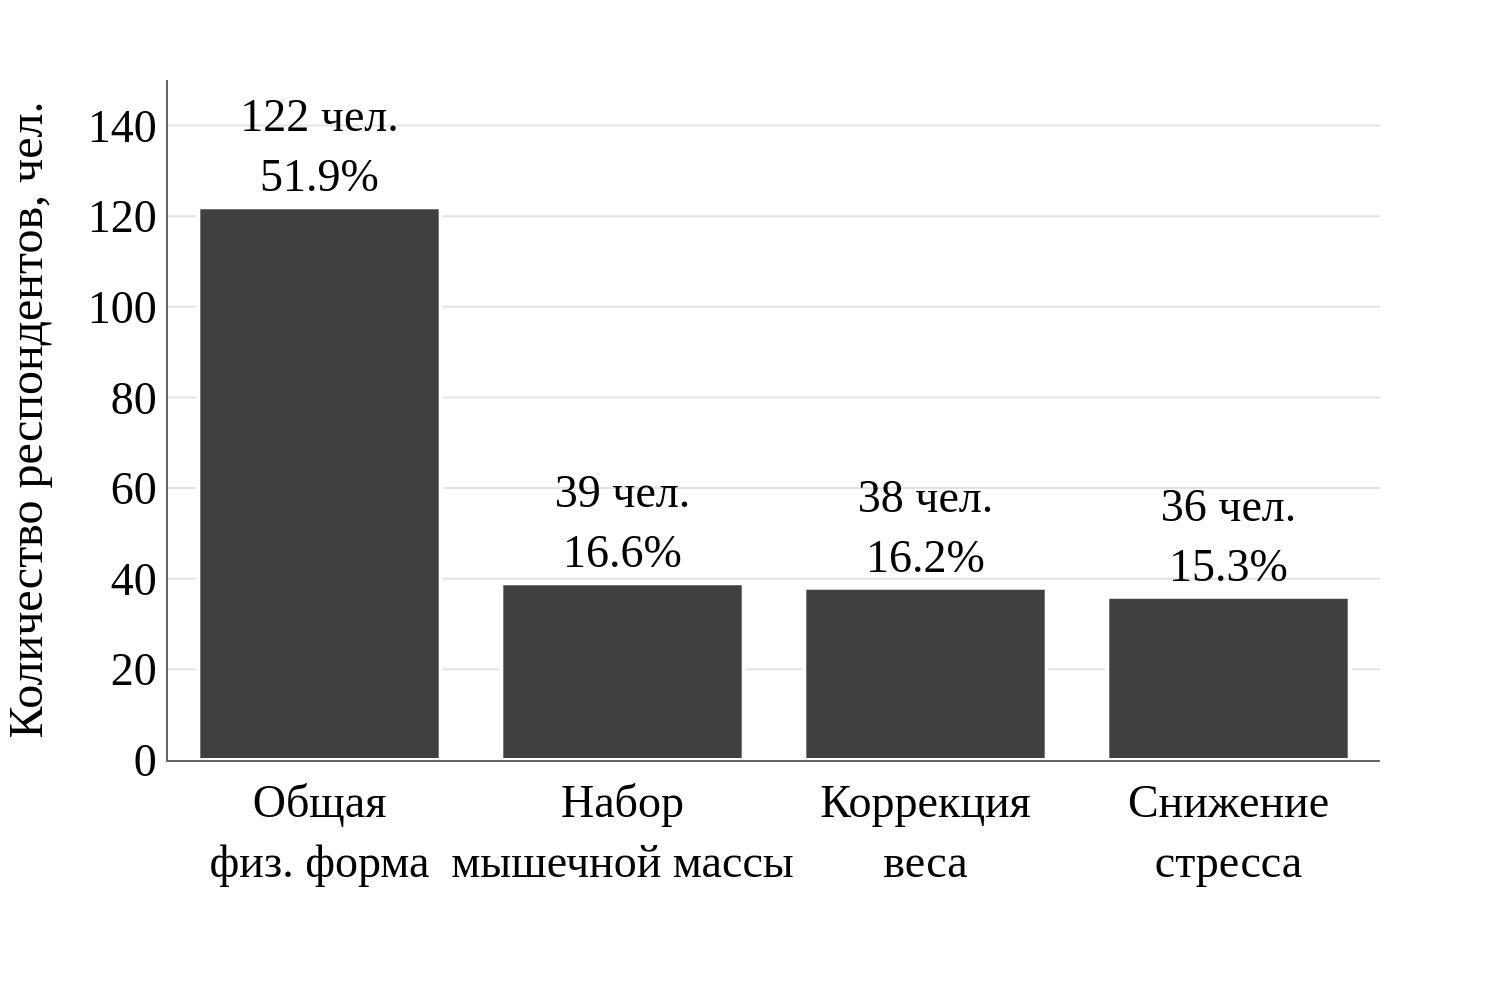

In [2]:
purpose_col = (
    "Which of the following would best describe your purpose "
    "to follow a wellness/fitness routine?"
)

purpose_data = (
    df[purpose_col]
    .dropna()
    .value_counts()
    .sort_values(ascending=False)
)

purpose_percent = (purpose_data / purpose_data.sum() * 100).round(1)

purpose_ru = {
    "General fitness/strength/flexibility/stamina": "Общая<br>физ. форма",
    "Weight loss/gain": "Коррекция<br>веса",
    "Body building": "Набор<br>мышечной массы",
    "Mindfulness and well-being": "Психологическое<br>благополучие",
    "Stress/anxiety reduction and/or attain mindfulness": "Снижение<br>стресса"
}

labels = [purpose_ru.get(x, x) for x in purpose_data.index]

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=purpose_data.values,
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(purpose_data.values, purpose_percent.values)
    ],
    textposition='outside',
    textfont=dict(
        size=23,
        color='#000000',
        family='Times New Roman'
    ),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(
        family='Times New Roman',
        size=23,
        color='#000000'
    ),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=23),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=24),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, purpose_data.max() * 1.23]
    ),
    margin=dict(
        l=60,
        r=60,
        t=40,
        b=120
    ),
    width=750
)

fig.show()